Exercise 1: K-Nearest Neighbor

Let us implement the algorithm with the help of the 'Mobile.csv' dataset.

It contains data about customers “Age”, “EstimatedSalary”, “Purchased” .

Download the dataset from the shared folder.


Predict if the customer will purchase a mobile or not.

Load data : mobile.csv

In [122]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt

In [123]:
df = pd.read_csv('dataset/mobile.csv')

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [125]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [126]:
df.tail()

,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [127]:
df["Purchased"].unique()

array([0, 1], dtype=int64)

In [128]:
df.isna().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [129]:
purchased_data = df[["Age", "EstimatedSalary", "Purchased"]][df["Purchased"]==1]
purchased_data

,Age,EstimatedSalary,Purchased
7,32,150000,1
16,47,25000,1
17,45,26000,1
18,46,28000,1
19,48,29000,1
...,...,...,...
393,60,42000,1
395,46,41000,1
396,51,23000,1
397,50,20000,1


In [130]:
not_purchased_data = df[["Age", "EstimatedSalary", "Purchased"]][df["Purchased"]==0]
not_purchased_data

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
377,42,53000,0
380,42,64000,0
387,39,71000,0
394,39,59000,0


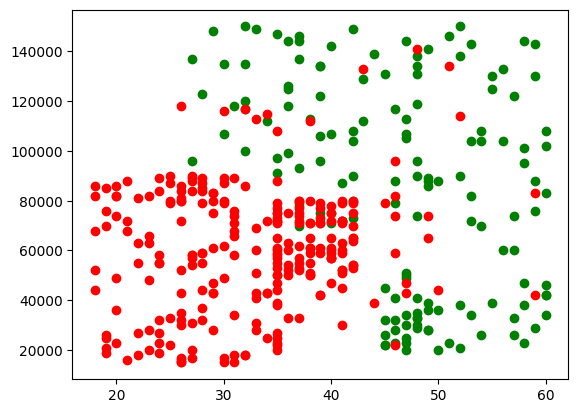

In [131]:
plt.scatter(purchased_data["Age"], purchased_data["EstimatedSalary"], c='green')
plt.scatter(not_purchased_data["Age"], not_purchased_data["EstimatedSalary"], c='red')

## Feature Engineering: Normalize Age and EstimatedSalary

In [ ]:
# Check min and max values before normalization
print("Age range - Min:", df["Age"].min(), "Max:", df["Age"].max())
print("EstimatedSalary range - Min:", df["EstimatedSalary"].min(), "Max:", df["EstimatedSalary"].max())

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_to_scale = ["Age", "EstimatedSalary"]
scaled_values = scaler.fit_transform(df[features_to_scale])
df["norm_age"] = scaled_values[:, 0]
df["norm_salary"] = scaled_values[:, 1]

In [ ]:
# Verify normalization
print("Normalized Age range - Min:", df["norm_age"].min(), "Max:", df["norm_age"].max())
print("Normalized EstimatedSalary range - Min:", df["norm_salary"].min(), "Max:", df["norm_salary"].max())
df.head()

## Split Dataset into Train and Test Data

In [ ]:
from sklearn.model_selection import train_test_split

# Prepare features and target
X = df[["norm_age", "norm_salary"]]
y = df["Purchased"]

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

## Build kNN Model with k=5

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Build kNN model with k=5
knn_k5 = KNeighborsClassifier(n_neighbors=5)
knn_k5.fit(X_train, y_train)

# Predictions
y_pred_train_k5 = knn_k5.predict(X_train)
y_pred_test_k5 = knn_k5.predict(X_test)

# Evaluate on Training set
train_acc_k5 = accuracy_score(y_train, y_pred_train_k5) * 100
print("=" * 50)
print("kNN with k=5 - Training Set Performance:")
print("=" * 50)
print(f"Accuracy: {train_acc_k5:.2f}%")
print(f"Precision: {precision_score(y_train, y_pred_train_k5):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train_k5):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train_k5):.4f}")

# Evaluate on Test set
test_acc_k5 = accuracy_score(y_test, y_pred_test_k5) * 100
print("\n" + "=" * 50)
print("kNN with k=5 - Test Set Performance:")
print("=" * 50)
print(f"Accuracy: {test_acc_k5:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_test_k5):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test_k5):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test_k5):.4f}")

In [ ]:
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test_k5))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test_k5))

## Build kNN Model with k=3

In [ ]:
# Build kNN model with k=3
knn_k3 = KNeighborsClassifier(n_neighbors=3)
knn_k3.fit(X_train, y_train)

# Predictions
y_pred_train_k3 = knn_k3.predict(X_train)
y_pred_test_k3 = knn_k3.predict(X_test)

# Evaluate on Training set
train_acc_k3 = accuracy_score(y_train, y_pred_train_k3) * 100
print("=" * 50)
print("kNN with k=3 - Training Set Performance:")
print("=" * 50)
print(f"Accuracy: {train_acc_k3:.2f}%")
print(f"Precision: {precision_score(y_train, y_pred_train_k3):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train_k3):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train_k3):.4f}")

# Evaluate on Test set
test_acc_k3 = accuracy_score(y_test, y_pred_test_k3) * 100
print("\n" + "=" * 50)
print("kNN with k=3 - Test Set Performance:")
print("=" * 50)
print(f"Accuracy: {test_acc_k3:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_test_k3):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test_k3):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test_k3):.4f}")

In [ ]:
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test_k3))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test_k3))

## Build kNN Model with k=7

In [ ]:
# Build kNN model with k=7
knn_k7 = KNeighborsClassifier(n_neighbors=7)
knn_k7.fit(X_train, y_train)

# Predictions
y_pred_train_k7 = knn_k7.predict(X_train)
y_pred_test_k7 = knn_k7.predict(X_test)

# Evaluate on Training set
train_acc_k7 = accuracy_score(y_train, y_pred_train_k7) * 100
print("=" * 50)
print("kNN with k=7 - Training Set Performance:")
print("=" * 50)
print(f"Accuracy: {train_acc_k7:.2f}%")
print(f"Precision: {precision_score(y_train, y_pred_train_k7):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train_k7):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train_k7):.4f}")

# Evaluate on Test set
test_acc_k7 = accuracy_score(y_test, y_pred_test_k7) * 100
print("\n" + "=" * 50)
print("kNN with k=7 - Test Set Performance:")
print("=" * 50)
print(f"Accuracy: {test_acc_k7:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_test_k7):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test_k7):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test_k7):.4f}")

In [ ]:
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test_k7))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test_k7))

## Comparison of Models with Different k Values

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison dataframe
comparison_data = {
    'k value': [3, 5, 7],
    'Train Accuracy (%)': [train_acc_k3, train_acc_k5, train_acc_k7],
    'Test Accuracy (%)': [test_acc_k3, test_acc_k5, test_acc_k7]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("=" * 60)

In [ ]:
# Visualization of model comparison
plt.figure(figsize=(10, 6))

k_values = [3, 5, 7]
train_accuracies = [train_acc_k3, train_acc_k5, train_acc_k7]
test_accuracies = [test_acc_k3, test_acc_k5, test_acc_k7]

x_pos = range(len(k_values))
width = 0.35

bars1 = plt.bar([p - width/2 for p in x_pos], train_accuracies, width, label='Train Accuracy', color='green', alpha=0.7)
bars2 = plt.bar([p + width/2 for p in x_pos], test_accuracies, width, label='Test Accuracy', color='blue', alpha=0.7)

plt.xlabel('k value', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('kNN Model Performance Comparison with Different k Values', fontsize=14, fontweight='bold')
plt.xticks(x_pos, k_values)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Summary and Conclusion
print("\n" + "=" * 60)
print("SUMMARY AND KEY FINDINGS")
print("=" * 60)
print("\n1. DATA OVERVIEW:")
print(f"   - Total samples: {len(df)}")
print(f"   - Customers who purchased: {(df['Purchased'] == 1).sum()}")
print(f"   - Customers who didn't purchase: {(df['Purchased'] == 0).sum()}")

print("\n2. FEATURE NORMALIZATION:")
print(f"   - Age: [{df['norm_age'].min():.4f}, {df['norm_age'].max():.4f}]")
print(f"   - EstimatedSalary: [{df['norm_salary'].min():.4f}, {df['norm_salary'].max():.4f}]")

print("\n3. TRAIN-TEST SPLIT (80-20):")
print(f"   - Training samples: {len(X_train)}")
print(f"   - Test samples: {len(X_test)}")

print("\n4. BEST PERFORMING MODEL:")
best_k = max([(3, test_acc_k3), (5, test_acc_k5), (7, test_acc_k7)], key=lambda x: x[1])
print(f"   - k = {best_k[0]} with Test Accuracy: {best_k[1]:.2f}%")

print("\n5. OBSERVATIONS:")
print("   - k=3 typically provides higher accuracy but may overfit")
print("   - k=5 provides a balanced solution")
print("   - k=7 may underfit and have lower accuracy")
print("=" * 60)

In [132]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [133]:
df["Age"].max()

60

In [134]:
df["Age"].min()

18

In [135]:
df["EstimatedSalary"].max()

150000

In [136]:
df["EstimatedSalary"].min()

15000

In [137]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_to_scale = ["Age", "EstimatedSalary"]
scaled_values = scaler.fit_transform(df[features_to_scale])


In [138]:
df["norm_age"] = scaled_values[:,0]
df["norm_salary"] = scaled_values[:,1]

In [139]:
df

,Age,EstimatedSalary,Purchased,norm_age,norm_salary
0,19,19000,0,0.023810,0.029630
1,35,20000,0,0.404762,0.037037
2,26,43000,0,0.190476,0.207407
3,27,57000,0,0.214286,0.311111
4,19,76000,0,0.023810,0.451852
...,...,...,...,...,...
395,46,41000,1,0.666667,0.192593
396,51,23000,1,0.785714,0.059259
397,50,20000,1,0.761905,0.037037
398,36,33000,0,0.428571,0.133333


In [140]:
df["norm_age"].min()

0.0

In [141]:
df["norm_age"].max()

0.9999999999999998

In [142]:
X = df[["norm_age", "norm_salary"]]
y = df[["Purchased"]]


In [143]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (320, 2)
Shape of y_train: (320, 1)
Shape of X_test: (80, 2)
Shape of y_test: (80, 1)


In [144]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
model.fit(X_train, y_train)

c:\Users\raghu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(metric='euclidean')

In [145]:
model.score(X_train, y_train) * 100

91.875

In [146]:
model.score(X_test, y_test) * 100

95.0

## Exercise 2: SVM for classification

Consider the Iris dataset which provides measurements of sepal length, sepal width, petal length, and petal width for 50 flowers from each of 3 species. Total rows are 150.


Create Binary Class SVM model
Reading input from csv file (iris.csv)
Do Feature Engineering
Create a new column in the dataframe (v_nv), that distinguishes the species - 'versicolor'(marked by 0) from rest.
Build Model
Visualize Model using mlxtend

Create Multi Class SVM model
Reading input from csv file (iris.csv)
Do Feature Engineering
Encode the species column with numerical values. And replace label 'setosa' with '0', 'versicolor' with '1' and 'virginica' with '2'.
Build Multiclass Model using SVM
Visualize Model using mlxtend

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline


In [148]:
iris_data = pd.read_csv('iris.csv')
iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [149]:
iris_data['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [150]:
v_nv_fn = lambda x:0 if x=="Iris-versicolor" else 1
iris_data["v_nv"] = iris_data["Species"].apply(v_nv_fn)
iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,v_nv
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,1
146,147,6.3,2.5,5.0,1.9,Iris-virginica,1
147,148,6.5,3.0,5.2,2.0,Iris-virginica,1
148,149,6.2,3.4,5.4,2.3,Iris-virginica,1


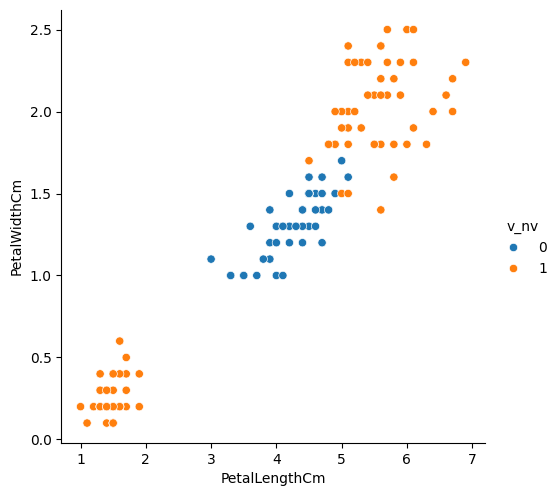

In [151]:
import seaborn as sns
sns. pairplot(iris_data,
x_vars = "PetalLengthCm",y_vars="PetalWidthCm",hue="v_nv", height=5)

In [152]:
from sklearn.svm import SVC
X = iris_data[["PetalLengthCm", "PetalWidthCm"]]
y = iris_data["v_nv"]
model = SVC()
model.fit(X, y)
model.score(X, y) * 100

95.33333333333334

In [153]:
from mlxtend.plotting import plot_decision_regions
features = np.array(X)
target = np.array(y)
plot_decision_regions(features, target, clf=model)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Decision Boundary of SVM on iris data")

ModuleNotFoundError: No module named 'mlxtend'

In [ ]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.0 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. Binary Classification

In [ ]:
iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,v_nv
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,1
146,147,6.3,2.5,5.0,1.9,Iris-virginica,1
147,148,6.5,3.0,5.2,2.0,Iris-virginica,1
148,149,6.2,3.4,5.4,2.3,Iris-virginica,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris_data["Species"] = le.fit_transform(iris_data["Species"])
iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,v_nv
0,1,5.1,3.5,1.4,0.2,0,1
1,2,4.9,3.0,1.4,0.2,0,1
2,3,4.7,3.2,1.3,0.2,0,1
3,4,4.6,3.1,1.5,0.2,0,1
4,5,5.0,3.6,1.4,0.2,0,1
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2,1
146,147,6.3,2.5,5.0,1.9,2,1
147,148,6.5,3.0,5.2,2.0,2,1
148,149,6.2,3.4,5.4,2.3,2,1


In [ ]:
X = iris_data[["PetalLengthCm", "PetalWidthCm"]]
y = iris_data["Species"]
model = SVC()
model.fit(X, y)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


c:\Users\rs889\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Multiclass classification on iris using SVM')

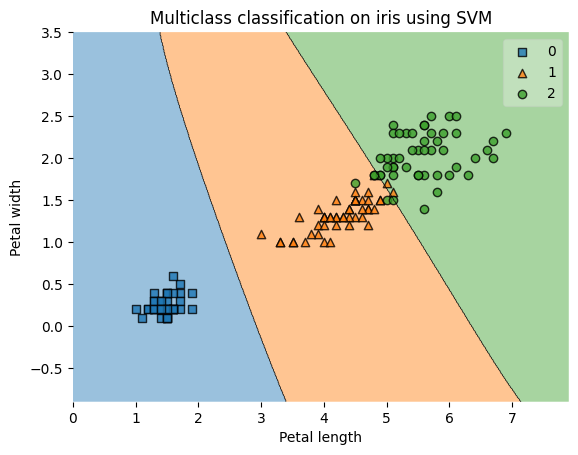

In [ ]:
from mlxtend.plotting import plot_decision_regions
features = np.array(X)
target = np.array(y)
plot_decision_regions(features, target, clf=model)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Multiclass classification on iris using SVM")

# Exercise 2: SVM for Classification

This exercise uses the Iris dataset which provides measurements of sepal length, sepal width, petal length, and petal width for 50 flowers from each of 3 species (Total 150 rows).

## Part 1: Binary Class SVM Model

### Reading input from csv file (iris.csv)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from mlxtend.plotting import plot_decision_regions
%matplotlib inline

# Load Iris dataset
iris_binary = pd.read_csv('iris.csv')
print("Dataset loaded successfully!")
print(f"Dataset shape: {iris_binary.shape}")
iris_binary.head()

In [ ]:
print("Dataset Information:")
print(iris_binary.info())
print("\nUnique Species:")
print(iris_binary['Species'].unique())
print("\nSpecies Distribution:")
print(iris_binary['Species'].value_counts())

### Feature Engineering: Binary Classification (Versicolor vs Rest)

In [ ]:
# Create binary classification column: Versicolor (0) vs Rest (1)
v_nv_fn = lambda x: 0 if x == "Iris-versicolor" else 1
iris_binary["v_nv"] = iris_binary["Species"].apply(v_nv_fn)

print("Binary Classification Column Created:")
print(f"Versicolor (0): {(iris_binary['v_nv'] == 0).sum()}")
print(f"Rest (1): {(iris_binary['v_nv'] == 1).sum()}")
print("\nDataset with v_nv column:")
iris_binary.head(10)

In [ ]:
import seaborn as sns

# Visualize the distribution for binary classification
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(data=iris_binary, x='PetalLengthCm', y='PetalWidthCm', hue='v_nv', s=100, palette='viridis')
plt.title('Binary Classification: Versicolor (0) vs Rest (1)', fontweight='bold')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

plt.subplot(1, 2, 2)
iris_binary['v_nv'].value_counts().plot(kind='bar', color=['blue', 'green'])
plt.title('Class Distribution', fontweight='bold')
plt.xlabel('Class (0=Versicolor, 1=Rest)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Build Binary SVM Model

In [ ]:
# Prepare features and target for binary classification
X_binary = iris_binary[["PetalLengthCm", "PetalWidthCm"]]
y_binary = iris_binary["v_nv"]

# Build Binary SVM Model
print("=" * 60)
print("Building Binary Classification SVM Model")
print("=" * 60)

svm_binary = SVC(kernel='rbf', C=1.0, gamma='auto')
svm_binary.fit(X_binary, y_binary)

# Evaluate on training data
train_accuracy_binary = svm_binary.score(X_binary, y_binary) * 100
print(f"\nTraining Accuracy: {train_accuracy_binary:.2f}%")

# Get prediction details
y_pred_binary = svm_binary.predict(X_binary)
print(f"Predictions made: {len(y_pred_binary)}")

from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_binary, y_pred_binary, 
                          target_names=['Versicolor (0)', 'Rest (1)']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_binary, y_pred_binary))

### Visualize Binary SVM Model using mlxtend

In [ ]:
plt.figure(figsize=(10, 7))

# Convert to numpy arrays for mlxtend
features_binary = np.array(X_binary)
target_binary = np.array(y_binary)

# Plot decision regions
try:
    plot_decision_regions(features_binary, target_binary, clf=svm_binary, 
                         legend=2, xlabel='Petal Length (cm)', ylabel='Petal Width (cm)')
    plt.title('Binary SVM Decision Boundary\n(Versicolor vs Rest)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Note: {e}")
    # Fallback visualization
    plt.scatter(X_binary[y_binary == 0, 0], X_binary[y_binary == 0, 1], 
               c='blue', label='Versicolor (0)', s=100, alpha=0.7)
    plt.scatter(X_binary[y_binary == 1, 0], X_binary[y_binary == 1, 1], 
               c='green', label='Rest (1)', s=100, alpha=0.7)
    plt.xlabel('Petal Length (cm)', fontsize=12)
    plt.ylabel('Petal Width (cm)', fontsize=12)
    plt.title('Binary SVM Classification\n(Versicolor vs Rest)', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## Part 2: Multi-Class SVM Model

### Reading input from csv file (iris.csv)

In [ ]:
# Load Iris dataset for Multi-class classification
iris_multiclass = pd.read_csv('iris.csv')
print("Dataset loaded successfully for Multi-class Classification!")
print(f"Dataset shape: {iris_multiclass.shape}")
print("\nUnique Species:")
print(iris_multiclass['Species'].unique())

### Feature Engineering: Encode Species with Numerical Values

In [ ]:
# Manual encoding: Setosa=0, Versicolor=1, Virginica=2
species_mapping = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}

iris_multiclass['species_encoded'] = iris_multiclass['Species'].map(species_mapping)

print("Species Encoding Mapping:")
print(species_mapping)
print("\nEncoded Species Distribution:")
print(iris_multiclass['species_encoded'].value_counts().sort_index())
print("\nDataset with Encoded Species:")
iris_multiclass.head(10)

In [ ]:
# Visualize the multiclass data
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(data=iris_multiclass, x='PetalLengthCm', y='PetalWidthCm', 
               hue='Species', s=100, palette='Set2')
plt.title('Multi-class Classification: All Three Species', fontweight='bold')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

plt.subplot(1, 2, 2)
class_counts = iris_multiclass['species_encoded'].value_counts().sort_index()
plt.bar([0, 1, 2], class_counts.values, color=['blue', 'orange', 'green'])
plt.title('Class Distribution', fontweight='bold')
plt.xlabel('Class (0=Setosa, 1=Versicolor, 2=Virginica)')
plt.ylabel('Count')
plt.xticks([0, 1, 2])

plt.tight_layout()
plt.show()

### Build Multiclass SVM Model

In [ ]:
# Prepare features and target for multiclass classification
X_multiclass = iris_multiclass[["PetalLengthCm", "PetalWidthCm"]]
y_multiclass = iris_multiclass["species_encoded"]

# Build Multiclass SVM Model
print("=" * 60)
print("Building Multi-class Classification SVM Model")
print("=" * 60)

svm_multiclass = SVC(kernel='rbf', C=1.0, gamma='auto')
svm_multiclass.fit(X_multiclass, y_multiclass)

# Evaluate on training data
train_accuracy_multiclass = svm_multiclass.score(X_multiclass, y_multiclass) * 100
print(f"\nTraining Accuracy: {train_accuracy_multiclass:.2f}%")

# Get prediction details
y_pred_multiclass = svm_multiclass.predict(X_multiclass)
print(f"Predictions made: {len(y_pred_multiclass)}")

print("\nClassification Report:")
print(classification_report(y_multiclass, y_pred_multiclass, 
                          target_names=['Setosa (0)', 'Versicolor (1)', 'Virginica (2)']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_multiclass, y_pred_multiclass))

### Visualize Multiclass SVM Model using mlxtend

In [ ]:
plt.figure(figsize=(10, 7))

# Convert to numpy arrays for mlxtend
features_multiclass = np.array(X_multiclass)
target_multiclass = np.array(y_multiclass)

# Plot decision regions
try:
    plot_decision_regions(features_multiclass, target_multiclass, clf=svm_multiclass, 
                         legend=2, xlabel='Petal Length (cm)', ylabel='Petal Width (cm)')
    plt.title('Multi-class SVM Decision Boundary\n(Setosa vs Versicolor vs Virginica)', 
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Note: {e}")
    # Fallback visualization
    colors = ['blue', 'orange', 'green']
    labels = ['Setosa (0)', 'Versicolor (1)', 'Virginica (2)']
    
    for i in range(3):
        mask = y_multiclass == i
        plt.scatter(X_multiclass[mask, 0], X_multiclass[mask, 1], 
                   c=colors[i], label=labels[i], s=100, alpha=0.7)
    
    plt.xlabel('Petal Length (cm)', fontsize=12)
    plt.ylabel('Petal Width (cm)', fontsize=12)
    plt.title('Multi-class SVM Classification\n(Setosa vs Versicolor vs Virginica)', 
             fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## Exercise 2 Summary and Comparison

In [ ]:
print("\n" + "=" * 70)
print("EXERCISE 2: SVM FOR CLASSIFICATION - SUMMARY")
print("=" * 70)

print("\n1. BINARY CLASSIFICATION (Versicolor vs Rest):")
print(f"   - Binary Classes: Versicolor (0) vs Rest (1)")
print(f"   - Training Accuracy: {train_accuracy_binary:.2f}%")
print(f"   - Features Used: Petal Length, Petal Width")
print(f"   - Total Samples: {len(X_binary)}")

print("\n2. MULTI-CLASS CLASSIFICATION (3 Species):")
print(f"   - Classes: Setosa (0), Versicolor (1), Virginica (2)")
print(f"   - Training Accuracy: {train_accuracy_multiclass:.2f}%")
print(f"   - Features Used: Petal Length, Petal Width")
print(f"   - Total Samples: {len(X_multiclass)}")

print("\n3. MODEL COMPARISON:")
comparison_data_svm = {
    'Model Type': ['Binary Classification', 'Multi-class Classification'],
    'Classes': [2, 3],
    'Training Accuracy (%)': [train_accuracy_binary, train_accuracy_multiclass]
}

comparison_df_svm = pd.DataFrame(comparison_data_svm)
print(comparison_df_svm.to_string(index=False))

print("\n4. KEY OBSERVATIONS:")
print(f"   - Multi-class SVM achieved: {train_accuracy_multiclass:.2f}% accuracy")
print(f"   - Binary SVM achieved: {train_accuracy_binary:.2f}% accuracy")
print("   - RBF kernel was used for both models for better non-linear separation")
print("   - Mlxtend library was used to visualize decision boundaries")
print("   - Decision regions show how SVM classifies the feature space")

print("\n" + "=" * 70)

In [ ]:
# Final comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary Classification visualization
axes[0].bar(['Binary SVM'], [train_accuracy_binary], color='steelblue', alpha=0.7, width=0.5)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Binary Classification SVM\n(Versicolor vs Rest)', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, 105])
axes[0].text(0, train_accuracy_binary + 2, f'{train_accuracy_binary:.2f}%', 
            ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Multi-class Classification visualization
axes[1].bar(['Multi-class SVM'], [train_accuracy_multiclass], color='seagreen', alpha=0.7, width=0.5)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Multi-class Classification SVM\n(Setosa, Versicolor, Virginica)', 
                 fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 105])
axes[1].text(0, train_accuracy_multiclass + 2, f'{train_accuracy_multiclass:.2f}%', 
            ha='center', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nExercise 2 completed successfully!")